# Analisis de reseñas de `MONZO`

Este notebook realiza un analisis completo con estos objetivos:

0. Extraccion y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empreesas dentro de la misma categoria
5. Conclusiones

## 1) Librerias

In [2]:
import re
import numpy as np
import pandas as pd

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline

## 2) Configuracion

In [3]:
MAX_ROWS = None                   # Limita las filas para pruebas rápidas, por ejemplo, 500.
TARGET = "www.monzo.com"          # Empresa objetivo del análisis.
CAT = "Money & Insurance"         # Categoría de la empresa objetivo.

N_TOPICS = 8                      # Número de temas a extraer.
TOP_WORDS = 12                    # Número de palabras más importantes por tema.
MIN_TOPIC_DOCS = 10               # Mínimo de documentos por tema para considerarlo relevante.

## 3) Carga de datos

Carga del dataset y conversión a dataframe

In [4]:
df = pd.read_csv("trustpilot-reviews-123k.csv")
df.head(3)

,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


In [5]:
df.shape

(123181, 6)

In [6]:
df.columns

Index(['category', 'company', 'description', 'title', 'review', 'stars'], dtype='str')

In [7]:
df[df["company"] == TARGET].shape

(100, 6)

## 4) Tipos de caracteres

### Observaciones iniciales

- Signos de puntuación (! , .)
- Mayúsculas/Minúsculas (m M)
- Emojis (😊)

In [63]:
# Muestra aleatoria
df['review'].sample(10).tolist()

['Good for surface paint scrapes only, would not recommend for reshaping and dent repair. Friendly and helpful technician resprayed scraped wheel arch and door and matched colour perfectly. Unfortunately managed to scuff the excellent paintwork they had just repaired during polishing stage. Missed small part of damage on wheel arch. Quoted one amount, on the day was told this excluded VAT, so had to pay around 10% more after discount code offered. Neighbour had same technician round following week for dent repair on their car, finished result looked awful.',
 'Customer service at Southern Comms is excellent.  Speed and accuracy!  They responded to our email very quickly and were able to solve the problems easily too.  We liked the follow-up email explaining what the problem was so we check this again in the future.',
 'Good quality wood. Larger cuts would be better ',
 "Extremely happy with my hive. Coming from manual switch on and off, it's marvellous to be able to control my heating 

### Longitud de los caracteres de las reseñas
- La longitud media es de 359 caracteres, mientras que la mediana se sitúa en 290 caracteres, lo que indica una distribución asimétrica con presencia de algunas reseñas muy extensas.
- El 50% de las reseñas tienen entre 177 y 440 caracteres, mientras que la reseña más larga alcanza los 9.956 caracteres (casi 10.000)
- La mayoría de las opiniones son relativamente breves, aunque existen algunos casos excepcionales con mucho más detalle, generando una distribución con cola larga hacia la derecha.

In [9]:
# Longitud de reseñas
df['review_len'] = df['review'].str.len()
df['review_len'].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

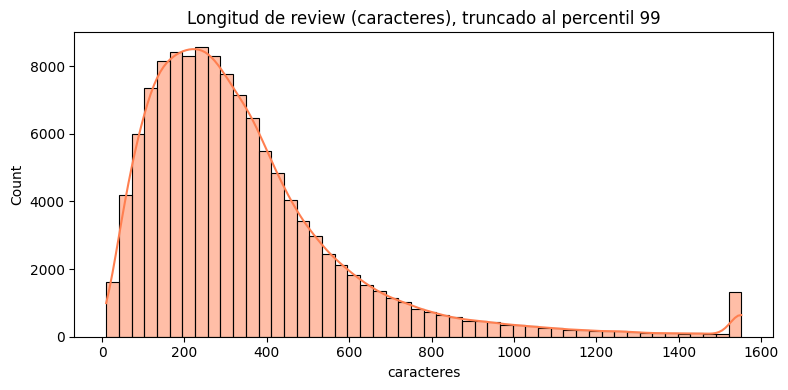

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

rl = df["review"].astype(str).str.len()
plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de review (caracteres), truncado al percentil 99")
plt.xlabel("caracteres")
plt.tight_layout()
plt.show()

### Caracteres especiales y ejemplos

In [11]:
reviews = df["review"].astype(str)

print("URLs:", reviews.str.contains(r"http|www", case=False, na=False).sum())
print("Hashtags:", reviews.str.contains(r"#\w+", na=False).sum())
print("Menciones:", reviews.str.contains(r"@\w+", na=False).sum())
print("Números:", reviews.str.contains(r"\d", na=False).sum())
print("Saltos de línea:", reviews.str.contains(r"\n", na=False).sum())
print("Signos de puntuación:", reviews.str.contains(r"[^\w\s]", regex=True, na=False).sum())

emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+",
    flags=re.UNICODE
)

emoji_count = reviews.apply(lambda x: bool(emoji_pattern.search(x))).sum()

print("Emojis:", emoji_count)

URLs: 19
Hashtags: 187
Menciones: 122
Números: 50327
Saltos de línea: 0
Signos de puntuación: 119039
Emojis: 2635


In [12]:
# URLs
df[reviews.str.contains(r"http|www", case=False, na=False)]["review"].head(3).tolist()

["Shipping is very fast, communication is non existent. I received the package 2 days after the order (10ml pure black), there was no invoice in the jiffy pack just the product. After further investigation on the internet I discovered that through numerous trials the effective dose for helping with sleep issues is 75mg to 100mg which equates to 12 doses in the bottle, which isn't much for the price. https//startsleeping.org https//dailycbd.comI'm on the large size and weigh over 250lb so my recommend dose is 76mg.CBD brothers recommend starting at 18mg and not to exceed 70mg. The packaging has a moon and stars on it denoting it's aimed at nighttime use. I emailed CBD brothers to get some clarification on the matter of dosing and the research findings and had no response at all. I toyed with sending the product back but thought I would give it a try and can say that at over 70mg it helps to relax but doesn't stop me from waking up during the night. The effectiveness of the product is mi

In [13]:
# Ejemplos con hashtags
df[reviews.str.contains(r"#\w+", na=False)]["review"].head(5).tolist()

['I placed an order ref: #28363236 (Saturday, 21 December 2024 at 5:44pm) with delivery showing as 30/12/24 to 02/01/25.Logged onto the site on the 30th of December to find my order status as: We are allocating stock in our warehouse to cover this order or waiting on suppliers for deliveries of stock in to us.I telephoned to chase and was told that 4 items were actually out of stock.I explained that when I ordered these it did not show that they were out of stock and that if it had I would not have ordered them.I have now had to cancel my order which also included my dog food and will need to look elsewhere for these which has wasted a lot of time. If you cannot fulfill orders due to your sock levels you should not show the products as in stock, and also keep your customers up to date a lot better. ',
 'I never received the product. Order#S000396758. Been waiting never got notifications when mailed. Very disappointed was hoping it would help my dog. ',
 'While the product is great, I w

In [14]:
# Ejemplos con menciones
df[reviews.str.contains(r"@\w+", na=False)]["review"].head(5).tolist()

["There is no regulation on how much vets can charge, so this whole industry is a very greedy free-for-all, especially the out of hours services.  Cynical too.  The welfare of animals is clearly not the reason companies like this exist.  It's a cold, hard money making machine whose target audience is captive one.  'Do you love your animal enough to find the money?'In fact, I had to weigh up not going vs. the potential risks to my cat on my recent visit (20.12.24) when I found out that VetsNow charge over £300 just for the visit with nothing else factored in. My diabetic cat was showing symptoms of Keto acidosis. I had to think about watching him all night and taking him to my vet first thing the next morning if he made it through, or only using this service if he suddenly collapsed.  But if it was keto, downhill could come too fast for help. Therefore, between a rock and a hard place, I took him, but decided that all I wanted from them was to rule out keto with a simple blood test.  No

In [15]:
# Ejemplos con números
df[reviews.str.contains(r"\d", na=False)]["review"].head(5).tolist()

['I’ve purchased first of those coats in May2020. Still goes strong although my girl is not with us anymore her little sister is still using it. I’ve bought a limited edition this year as a Christmas gift for my current dog so she has also one of her own.My dog is notorious at rolling so needs to be washed pretty much every day. Those coats are a life saver. Dry dog and no shivering within 20 min. So glad I’ve found the brand. Highly recommend it for any dog parent. ',
 'Great company and products. This is my 3rd drying robe, amazed how quickly my dog drys when wearing these robes. Excellent quality products, quick delivery. ',
 'This is the 4th purchase, not because anything was wrong but puppies grow and then the older boy can’t be outdone by the new puppy so he needed a new one as well 😂These drying coats are fantastic, warm, thick, wash brilliantly and look great. Once on, they are spaniel proof Would highly recommend ',
 'Well, nothing else but just GREAT. In love with all the pro

In [16]:
# Saltos de línea
df[reviews.str.contains(r"\n", na=False)]["review"].head(3).tolist()

[]

In [17]:
punct_reviews = df[
    reviews.str.contains(r"[^\w\s]", regex=True, na=False)
]

punct_reviews["review"].head(5).tolist()

['Really prompt service, The sofa covers have not moved since being put on despite the efforts of three cocker spaniels!Helpful staff who delayed delivery on request because I would be away for delivery. ',
 'I’ve purchased first of those coats in May2020. Still goes strong although my girl is not with us anymore her little sister is still using it. I’ve bought a limited edition this year as a Christmas gift for my current dog so she has also one of her own.My dog is notorious at rolling so needs to be washed pretty much every day. Those coats are a life saver. Dry dog and no shivering within 20 min. So glad I’ve found the brand. Highly recommend it for any dog parent. ',
 'Brilliant coats. Really like the limited edition raspberry and chocolate colour combo. Do a great job of warming and drying cold, wet, tired dogs after a day on the shoot. Generously sized and do take a while to dry once off the dog, but overall very happy. 😃 ',
 'Great company and products. This is my 3rd drying ro

In [18]:
# Emojis
df[reviews.apply(lambda x: bool(emoji_pattern.search(x)))]["review"].head(3).tolist()

['Brilliant coats. Really like the limited edition raspberry and chocolate colour combo. Do a great job of warming and drying cold, wet, tired dogs after a day on the shoot. Generously sized and do take a while to dry once off the dog, but overall very happy. 😃 ',
 'This is the 4th purchase, not because anything was wrong but puppies grow and then the older boy can’t be outdone by the new puppy so he needed a new one as well 😂These drying coats are fantastic, warm, thick, wash brilliantly and look great. Once on, they are spaniel proof Would highly recommend ',
 'Very good quality coat, ordered wrong size, company very responsive and helpful in a bid to resolve the matter! But woe betide anyone trying to do a return, I have actually given up and just put it in cupboard 😫']

## 5) Limpieza

Tras revisar los caracteres presentes en las reseñas, se observa que existen signos de puntuación, números, emojis, hashtags, menciones y algunas URLs.

Para preparar el texto para el análisis NLP, se construye una función de limpieza que:
- Convierte el texto a minúsculas.
- Elimina URLs.
- Elimina menciones y hashtags.
- Elimina signos de puntuación, números y caracteres especiales.
- Normaliza espacios en blanco.

Esta limpieza permite reducir ruido textual y mejorar la extracción posterior de topics.

In [19]:
def clean_text(text):

    text = str(text).lower()

    # Eliminar URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Eliminar menciones y hashtags
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # Elimiinar signos de puntuación pero mantener letras y números
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalizar espacios
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [20]:
df["review_clean"] = df["review"].apply(clean_text)

df[["review", "review_clean"]].head(10)

,review,review_clean
0,Great quality dog drying robe although had to ...,great quality dog drying robe although had to ...
1,"Really prompt service, The sofa covers have no...",really prompt service the sofa covers have not...
2,I’ve purchased first of those coats in May2020...,i ve purchased first of those coats in may2020...
3,Brilliant coats. Really like the limited editi...,brilliant coats really like the limited editio...
4,Great company and products. This is my 3rd dry...,great company and products this is my 3rd dryi...
5,Excellent good quality products. Found exactly...,excellent good quality products found exactly ...
6,Worth the MoneyA bit more expensive than I wou...,worth the moneya bit more expensive than i wou...
7,"This is the 4th purchase, not because anything...",this is the 4th purchase not because anything ...
8,"Well, nothing else but just GREAT. In love wit...",well nothing else but just great in love with ...
9,I have had several of you items and each one i...,i have had several of you items and each one i...


In [21]:
df["review_clean_len"] = df["review_clean"].str.len()

# Revisión de la longitud de las reseñas limpias
df["review_clean_len"].describe()

count    123181.000000
mean        351.115448
std         308.172769
min           0.000000
25%         173.000000
50%         284.000000
75%         430.000000
max        9626.000000
Name: review_clean_len, dtype: float64

## 6) Sector de la compañía objetivo

Se filtran las reseñas pertenecientes al sector "Money & Insurance" para comparar la compañía objetivo con empresas que operan en un entorno competitivo similar.

Dentro de este sector se identifica a www.monzo.com como empresa objetivo para el análisis de sentimiento, extracción de topics y benchmarking frente a la competencia.

In [22]:
sector_df = df[df["category"] == CAT].copy()

print(f"Sector: {CAT}")
print(f"Reviews: {sector_df.shape[0]}")
print(f"Empresas: {sector_df['company'].nunique()}")

Sector: Money & Insurance
Reviews: 5729
Empresas: 70


In [23]:
sector_df["company"].value_counts().head(20)

company
smallworldfs.com                 100
www.cashback.co.uk               100
getyourtaxreturned.co.uk         100
saladmoney.co.uk                 100
www.unbiased.co.uk               100
www.firstdirect.com              100
wise.com                         100
blockchain.com                   100
uk.virginmoney.com               100
chase.co.uk                      100
www.monzo.com                    100
zopa.com                         100
tsb.co.uk                        100
transfergo.com                   100
kraken.com                       100
www.tescobank.com                100
tide.co                          100
www.startlinemotorfinance.com    100
www.aldermore.co.uk              100
www.quidco.com                   100
Name: count, dtype: int64

## 7) Sentimiento

El análisis de sentimiento muestra que el 69% de las reseñas de www.monzo.com presentan un sentimiento negativo, frente a un 31% de reseñas positivas. Este resultado sugiere una percepción predominantemente negativa por parte de los clientes que han decidido dejar una opinión en Trustpilot. 

No obstante, es importante considerar que las plataformas de reseñas suelen presentar un sesgo hacia experiencias extremas, especialmente negativas, por lo que los resultados deben interpretarse como una medida de la satisfacción expresada públicamente y no necesariamente de la totalidad de la base de clientes.

In [24]:
company_df = sector_df[sector_df["company"] == TARGET].copy()

print(company_df.shape)

(100, 9)


In [25]:
company_df["review_clean"] = company_df["review"].apply(clean_text)

In [26]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [27]:
company_df["sentiment"] = company_df["review_clean"].apply(
    lambda x: sentiment_model(x[:512])[0]["label"]
)

In [28]:
company_df["sentiment"].value_counts()

sentiment
NEGATIVE    69
POSITIVE    31
Name: count, dtype: int64

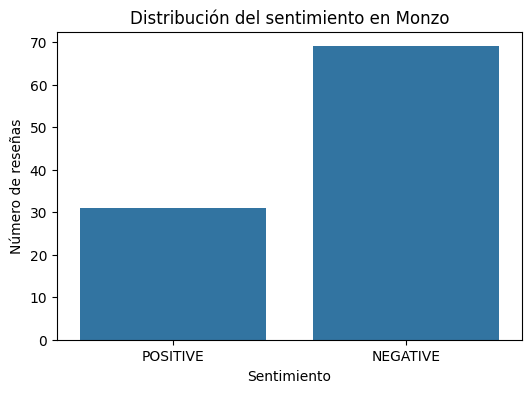

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=company_df,
    x="sentiment"
)

plt.title("Distribución del sentimiento en Monzo")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")

plt.show()

## 8) Topics



Los topics identificados muestran que las reseñas de Monzo se concentran principalmente en problemas con app, soporte y transacciones; tarjeta, pagos y bloqueos; atención al cliente; y cierre de cuentas o bloqueo de fondos.

También aparecen topics positivos asociados a facilidad de uso, experiencia bancaria, ahorro, uso internacional y control del gasto.

No se usó BERTopic porque entraba en conflicto con mi versión de Python (3.14). Se ha empleado TF-IDF + NMF. Técnica robusta, interpretable y estable para extracción de topics en datasets de reseñas. Esta aproximación permite identificar grupos de palabras relevantes y asignar cada reseña a un tema dominante de forma clara y explicable.

In [30]:
texts = company_df["review_clean"].dropna().tolist()

vectorizer = TfidfVectorizer(
    max_df=0.90,
    min_df=2,
    stop_words="english",
    ngram_range=(1, 2)
)

tfidf = vectorizer.fit_transform(texts)

nmf_model = NMF(
    n_components=N_TOPICS,
    random_state=42,
    init="nndsvda",
    max_iter=500
)

W = nmf_model.fit_transform(tfidf)
H = nmf_model.components_

feature_names = vectorizer.get_feature_names_out()

In [31]:
topics = []

for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[:-TOP_WORDS - 1:-1]]
    topics.append({
        "topic": topic_idx,
        "keywords": ", ".join(top_words)
    })

topics_df = pd.DataFrame(topics)
topics_df

,topic,keywords
0,0,"love, easy, monzo, love monzo, pots, future, l..."
1,1,"customer service, service, customer, speak, ap..."
2,2,"account, closed, reason, bank, money, funds, m..."
3,3,"better, cash, bank, good, changing, pretty, pr..."
4,4,"best, rate, international, saving, abroad, int..."
5,5,"monzo, issues, app, support, transaction, lost..."
6,6,"card, pay, good, blocked, just, phone, new car..."
7,7,"money, spending, don, simple, need, like, cont..."


In [32]:
company_df["topic"] = W.argmax(axis=1)
company_df["topic_score"] = W.max(axis=1)

company_df[["review", "sentiment", "topic", "topic_score"]].head()

,review,sentiment,topic,topic_score
56668,Monzo has changed banking apps for the better....,POSITIVE,7,0.378991
56669,"In one month with Monzo, I achieved what nearl...",POSITIVE,5,0.297664
56670,I use Monzo for international transactions and...,POSITIVE,4,0.560136
56671,This bank is excellent. Everything is so easy ...,POSITIVE,0,0.138067
56672,"Easy, secure and fast transaction. I have been...",POSITIVE,4,0.335744


In [33]:
topic_counts = (
    company_df["topic"]
    .value_counts()
    .sort_index()
    .reset_index()
)

topic_counts.columns = ["topic", "n_reviews"]
topic_counts["pct_reviews"] = (topic_counts["n_reviews"] / len(company_df) * 100).round(1)

topic_counts = topic_counts.merge(topics_df, on="topic")
topic_counts

,topic,n_reviews,pct_reviews,keywords
0,0,11,11.0,"love, easy, monzo, love monzo, pots, future, l..."
1,1,12,12.0,"customer service, service, customer, speak, ap..."
2,2,12,12.0,"account, closed, reason, bank, money, funds, m..."
3,3,10,10.0,"better, cash, bank, good, changing, pretty, pr..."
4,4,9,9.0,"best, rate, international, saving, abroad, int..."
5,5,18,18.0,"monzo, issues, app, support, transaction, lost..."
6,6,16,16.0,"card, pay, good, blocked, just, phone, new car..."
7,7,12,12.0,"money, spending, don, simple, need, like, cont..."


In [34]:
topic_names = {
    0: "Experiencia positiva y facilidad de uso",
    1: "Atención al cliente y soporte",
    2: "Cierre de cuentas y bloqueo de fondos",
    3: "Comparativa bancaria y uso de efectivo",
    4: "Uso internacional y ahorro",
    5: "Problemas con app, soporte y transacciones",
    6: "Tarjeta, pagos y bloqueos",
    7: "Gestión del dinero y control del gasto"
}

company_df["topic_name"] = company_df["topic"].map(topic_names)
topic_counts["topic_name"] = topic_counts["topic"].map(topic_names)

topic_counts[["topic", "topic_name", "n_reviews", "pct_reviews", "keywords"]]

,topic,topic_name,n_reviews,pct_reviews,keywords
0,0,Experiencia positiva y facilidad de uso,11,11.0,"love, easy, monzo, love monzo, pots, future, l..."
1,1,Atención al cliente y soporte,12,12.0,"customer service, service, customer, speak, ap..."
2,2,Cierre de cuentas y bloqueo de fondos,12,12.0,"account, closed, reason, bank, money, funds, m..."
3,3,Comparativa bancaria y uso de efectivo,10,10.0,"better, cash, bank, good, changing, pretty, pr..."
4,4,Uso internacional y ahorro,9,9.0,"best, rate, international, saving, abroad, int..."
5,5,"Problemas con app, soporte y transacciones",18,18.0,"monzo, issues, app, support, transaction, lost..."
6,6,"Tarjeta, pagos y bloqueos",16,16.0,"card, pay, good, blocked, just, phone, new car..."
7,7,Gestión del dinero y control del gasto,12,12.0,"money, spending, don, simple, need, like, cont..."


# 9) Visualizaciones

In [35]:
#%pip install wordcloud

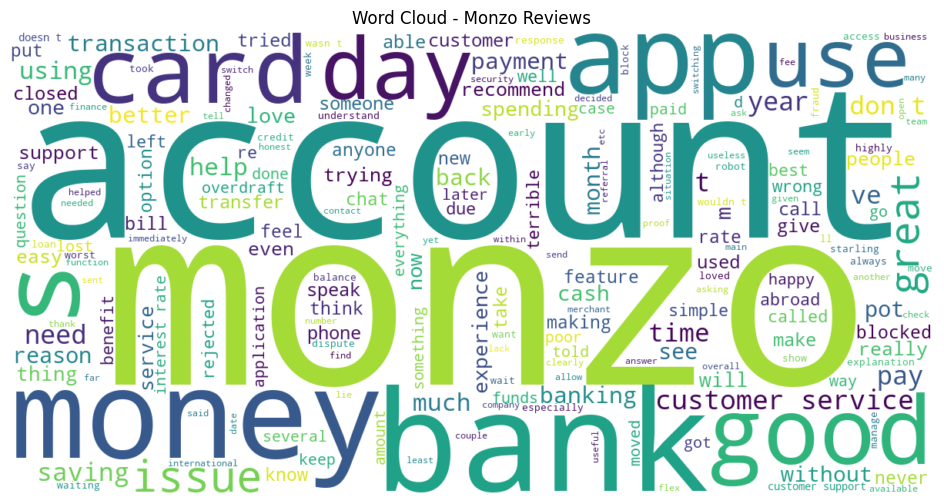

In [36]:
from wordcloud import WordCloud

text = " ".join(company_df["review_clean"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Monzo Reviews")
plt.show()

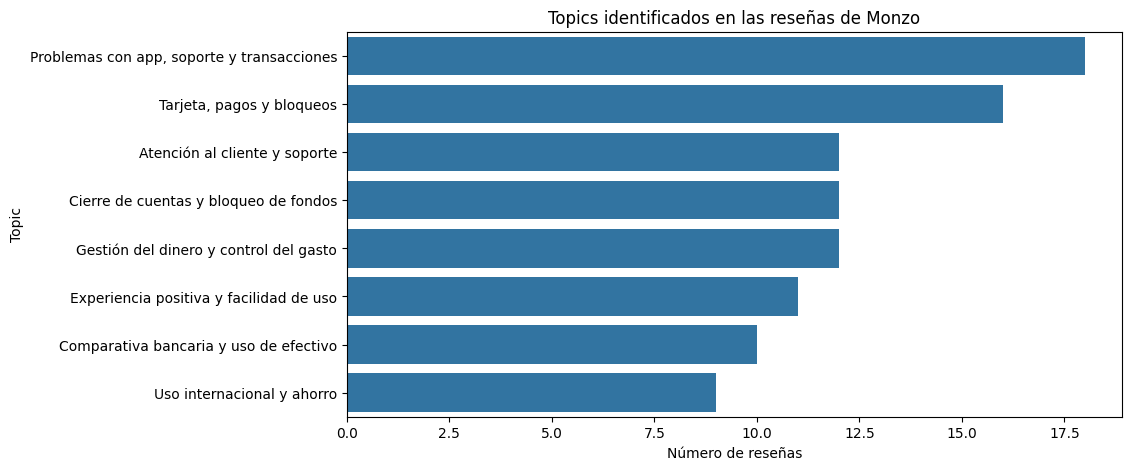

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=topic_counts.sort_values("n_reviews", ascending=False),
    x="n_reviews",
    y="topic_name"
)

plt.title("Topics identificados en las reseñas de Monzo")
plt.xlabel("Número de reseñas")
plt.ylabel("Topic")

plt.show()

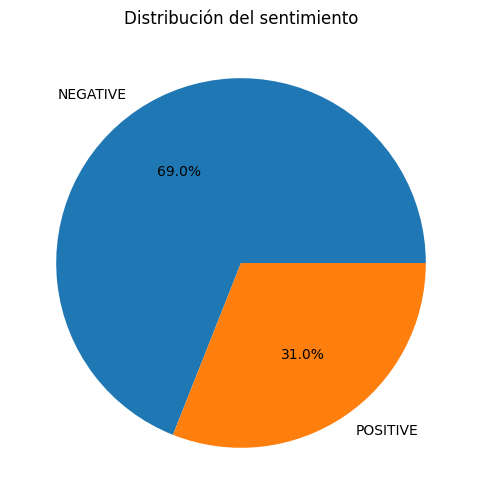

In [38]:
sentiment_counts = company_df["sentiment"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribución del sentimiento")
plt.show()

In [39]:
company_df.groupby(["topic_name","sentiment"]).size()

topic_name                                  sentiment
Atención al cliente y soporte               NEGATIVE     11
                                            POSITIVE      1
Cierre de cuentas y bloqueo de fondos       NEGATIVE     12
Comparativa bancaria y uso de efectivo      NEGATIVE      6
                                            POSITIVE      4
Experiencia positiva y facilidad de uso     NEGATIVE      4
                                            POSITIVE      7
Gestión del dinero y control del gasto      NEGATIVE      6
                                            POSITIVE      6
Problemas con app, soporte y transacciones  NEGATIVE     14
                                            POSITIVE      4
Tarjeta, pagos y bloqueos                   NEGATIVE     14
                                            POSITIVE      2
Uso internacional y ahorro                  NEGATIVE      2
                                            POSITIVE      7
dtype: int64

# 10) Benchmarking

In [40]:
sector_df["company"].value_counts().head(15)

company
smallworldfs.com            100
www.cashback.co.uk          100
getyourtaxreturned.co.uk    100
saladmoney.co.uk            100
www.unbiased.co.uk          100
www.firstdirect.com         100
wise.com                    100
blockchain.com              100
uk.virginmoney.com          100
chase.co.uk                 100
www.monzo.com               100
zopa.com                    100
tsb.co.uk                   100
transfergo.com              100
kraken.com                  100
Name: count, dtype: int64

In [41]:
# Seleccionamos empresas del mismo sector con 100 reseñas
top_companies = (
    sector_df["company"]
    .value_counts()
    .head(9)
    .index
    .tolist()
)

if TARGET not in top_companies:
    top_companies.append(TARGET)

top_companies

['smallworldfs.com',
 'www.cashback.co.uk',
 'getyourtaxreturned.co.uk',
 'saladmoney.co.uk',
 'www.unbiased.co.uk',
 'www.firstdirect.com',
 'wise.com',
 'blockchain.com',
 'uk.virginmoney.com',
 'www.monzo.com']

In [42]:
benchmark_df = sector_df[
    sector_df["company"].isin(top_companies)
].copy()

In [43]:
# Aplicamos sentimiento a todas las reviews del benchmark
benchmark_df["sentiment"] = benchmark_df["review_clean"].apply(
    lambda x: sentiment_model(x[:512])[0]["label"]
)

In [44]:
# Resumen de sentimiento por empresa
benchmark_sentiment = (
    benchmark_df
    .groupby(["company", "sentiment"])
    .size()
    .reset_index(name="n_reviews")
)

benchmark_sentiment

,company,sentiment,n_reviews
0,blockchain.com,NEGATIVE,78
1,blockchain.com,POSITIVE,22
2,getyourtaxreturned.co.uk,NEGATIVE,70
3,getyourtaxreturned.co.uk,POSITIVE,30
4,saladmoney.co.uk,NEGATIVE,60
5,saladmoney.co.uk,POSITIVE,40
6,smallworldfs.com,NEGATIVE,75
7,smallworldfs.com,POSITIVE,25
8,uk.virginmoney.com,NEGATIVE,71
9,uk.virginmoney.com,POSITIVE,29


In [45]:
# Pasamos a formato tabla
benchmark_pivot = (
    benchmark_sentiment
    .pivot(index="company", columns="sentiment", values="n_reviews")
    .fillna(0)
    .reset_index()
)

benchmark_pivot["total_reviews"] = benchmark_pivot["NEGATIVE"] + benchmark_pivot["POSITIVE"]
benchmark_pivot["positive_pct"] = (benchmark_pivot["POSITIVE"] / benchmark_pivot["total_reviews"] * 100).round(1)
benchmark_pivot["negative_pct"] = (benchmark_pivot["NEGATIVE"] / benchmark_pivot["total_reviews"] * 100).round(1)

benchmark_pivot = benchmark_pivot.sort_values("positive_pct", ascending=False)

benchmark_pivot

sentiment,company,NEGATIVE,POSITIVE,total_reviews,positive_pct,negative_pct
2,saladmoney.co.uk,60,40,100,40.0,60.0
8,www.monzo.com,69,31,100,31.0,69.0
1,getyourtaxreturned.co.uk,70,30,100,30.0,70.0
4,uk.virginmoney.com,71,29,100,29.0,71.0
5,wise.com,73,27,100,27.0,73.0
6,www.cashback.co.uk,74,26,100,26.0,74.0
3,smallworldfs.com,75,25,100,25.0,75.0
7,www.firstdirect.com,76,24,100,24.0,76.0
9,www.unbiased.co.uk,77,23,100,23.0,77.0
0,blockchain.com,78,22,100,22.0,78.0


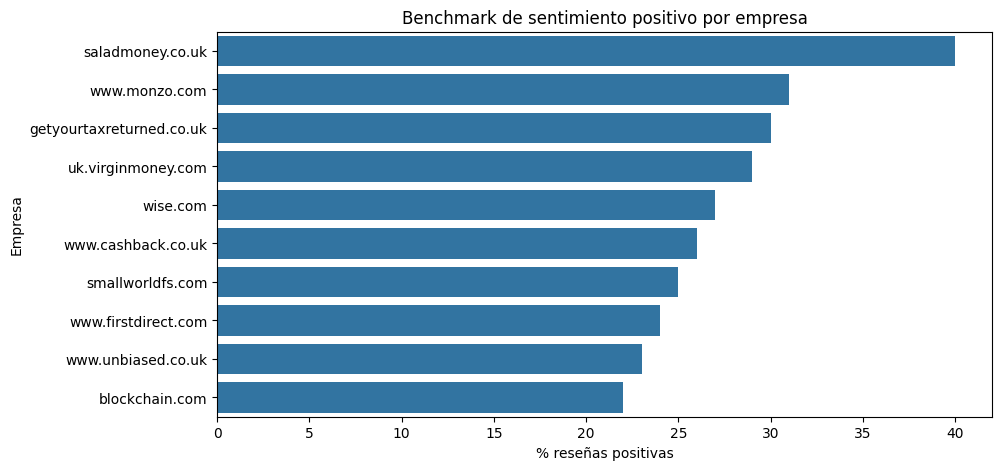

In [46]:
# Gráfico benchmark sentimiento positivo
plt.figure(figsize=(10,5))

sns.barplot(
    data=benchmark_pivot,
    x="positive_pct",
    y="company"
)

plt.title("Benchmark de sentimiento positivo por empresa")
plt.xlabel("% reseñas positivas")
plt.ylabel("Empresa")

plt.show()

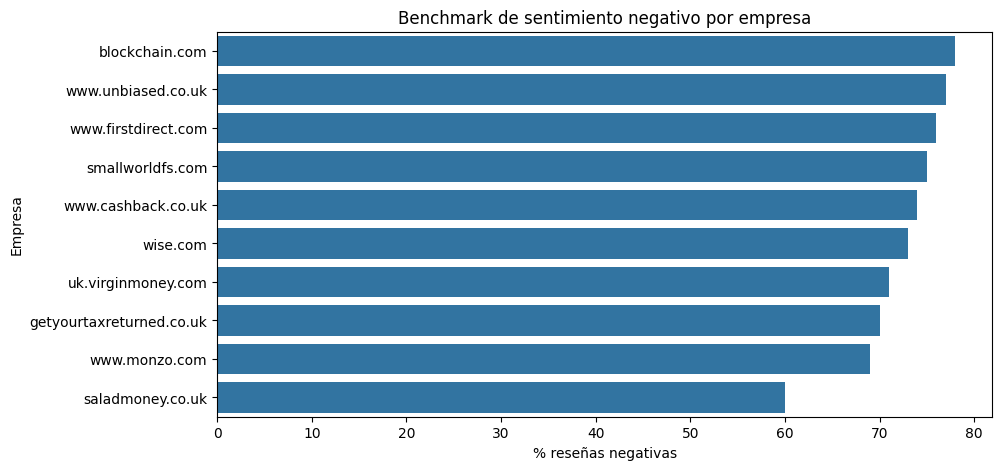

In [ ]:
# Comparación negativa
plt.figure(figsize=(10,5))

sns.barplot(
    data=benchmark_pivot.sort_values("negative_pct", ascending=False),
    x="negative_pct",
    y="company"
)

plt.title("Benchmark de sentimiento negativo por empresa")
plt.xlabel("% reseñas negativas")
plt.ylabel("Empresa")

plt.show()

In [48]:
benchmark_pivot[benchmark_pivot["company"] == TARGET]

sentiment,company,NEGATIVE,POSITIVE,total_reviews,positive_pct,negative_pct
8,www.monzo.com,69,31,100,31.0,69.0
